In [156]:
def func_S(num, shift=2):
    num = int(str(num)[-shift:] + str(num)[:-shift])
    return num

In [157]:
func_S(14568)

68145

In [158]:
def func_H(num1, num2):
    
    bin_max = bin(max(num1, num2))
    bin_min = bin(min(num1, num2))
    #print(bin_max, bin_min, sep='\n ')
    
    ind = 0
    lmin = len(bin_min)
    lmax = len(bin_max)
    
    while ind < lmin - 2:
        xor = int(bin_max[lmax - ind - 1]) ^ int(bin_min[lmin - ind - 1])
        if xor == 1:
            el = '1'
        else:
            el = '0'
        bin_max = bin_max[:lmax - ind - 1] + el + bin_max[lmax - ind:]
        #print(bin_max)
        
        ind += 1
        
    return int(bin_max, 2)

In [159]:
func_H(12, 23)

27

In [160]:
def random_7(r_0, k1=1234, k2=5678, M=1973):
    num = str(r_0)
    L = num[:len(num) // 2]
    R = num[len(num) // 2:]
    
    L += str(func_H(int(R), k1))
    
    R += str(func_S(int(L)))
    
    L += str(func_H(int(R), k2))
    
    result = int(L + R) % M
    return result

In [161]:
random_7(58)

1967

In [168]:
def my_random(r_0=123456, steps=24, M=1973, shift=2):
    r = str(r_0)
    
    for i in range(steps):
        #len_r = len(r)
        
        r_1 = r[-2:] + r[:-2]
        r_2 = r[2:] + r[:2]
        
        #print(r_1, r_2)
        
        r = str((int(r_1) + int(r_2)) % M) 
    return int(r) % M

In [169]:
my_random()

1038

In [170]:
import time 
M = 1973


rand_arr = [0] * M
print(rand_arr)
N = 10000

for i in range(N):
    current_time = time.time()
    milliseconds = int(current_time * 100000)
    
    ind = random_7(r_0=milliseconds, M=M)
    
    rand_arr[ind] += 1
    
sum(rand_arr)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

10000

<BarContainer object of 1973 artists>

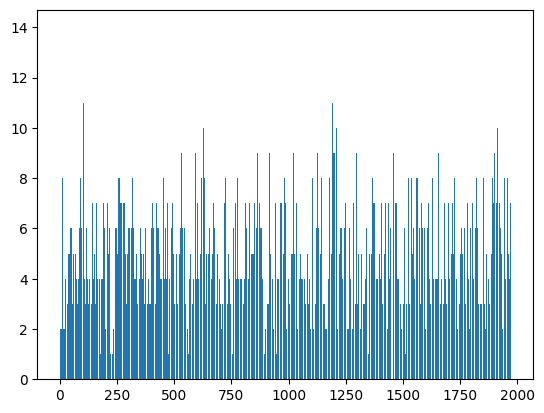

In [171]:
import matplotlib.pyplot as plt

x = [ind for ind in range(M)]

plt.bar(x, rand_arr)

In [172]:
def hi_sq(arr):
    k = 20
    
    p = 1 / k
    
    arr_n = [0] * k
    ps = []
    iter_p = 1
    print(len(arr), sum(arr))
    
    for i in range(len(arr)):
        if i / M >= iter_p * p:
            ps.append(iter_p * p)
            iter_p += 1
        arr_n[iter_p - 1] += arr[i]
    
    print(arr_n)
    ps.append(iter_p * p)
    plt.scatter(ps, arr_n)
    plt.scatter(ps, [N / k] * k)
    
    hi = 0
    for i in range(len(arr_n)):
        hi += (arr_n[i] - N * p)**2 / (N * p)
    return hi / N

1973 10000
[495, 513, 487, 511, 488, 512, 504, 512, 497, 478, 495, 513, 514, 501, 516, 486, 491, 490, 503, 494]


0.0004988000000000001

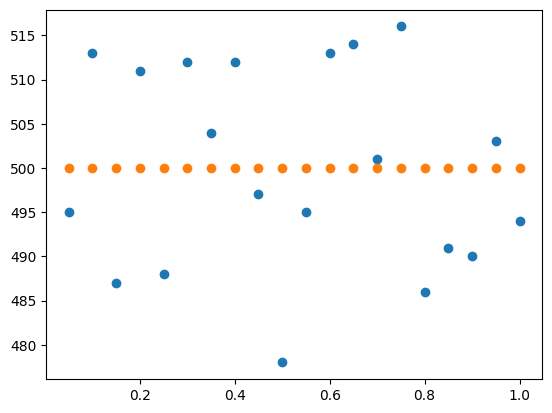

In [173]:
hi_sq(rand_arr)